In [2]:
%pip install kagglehub


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ulnnproject/food-freshness-dataset")

print("Path to dataset files:", path)

C:\Users\navad\PycharmProjects\PythonProject4\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\navad\.cache\kagglehub\datasets\ulnnproject\food-freshness-dataset\versions\1


In [1]:
%pip install tensorflow keras matplotlib scikit-learn opencv-python


  Using cached tensorflow-2.20.0-cp311-cp311-win_amd64.whl.metadata (4.6 kB)
  Using cached keras-3.11.3-py3-none-any.whl.metadata (5.9 kB)
  Using cached matplotlib-3.10.6-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached scikit_learn-1.7.1-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl.metadata (19 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-6.32.0-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached termcolor-3.1.0-py3-none-any.whl.metadata (6.4 


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [5]:
dataset_path = r"C:\Users\navad\PycharmProjects\PythonProject4\datasets\ulnnproject\food-freshness-dataset\versions\1\Dataset"


In [6]:
categories = os.listdir(dataset_path)
print("Detected categories:", categories)

Detected categories: ['Fresh', 'Rotten']


In [7]:
# -------------------------------
# 5. Load dataset (fixed)
# -------------------------------
data = []
labels = []
img_size = 128
for idx, category in enumerate(categories):
    category_folder = os.path.join(dataset_path, category)
    if not os.path.isdir(category_folder):
        continue
    for subfolder in os.listdir(category_folder):
        subfolder_path = os.path.join(category_folder, subfolder)
        if not os.path.isdir(subfolder_path):
            continue

        for img_name in os.listdir(subfolder_path):
            img_path = os.path.join(subfolder_path, img_name)
            try:
                img = cv2.imread(img_path)
                img = cv2.resize(img, (img_size, img_size))
                data.append(img)
                labels.append(idx)
            except:
                print("Error loading:", img_path)

data = np.array(data) / 255.0
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)


Data shape: (61370, 128, 128, 3)
Labels shape: (61370,)


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 128
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2  # split dataset into train/val automatically
)

# Train generator
train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Validation generator
val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

print("✅ Classes detected:", train_generator.class_indices)


Found 49084 images belonging to 2 classes.
Found 12270 images belonging to 2 classes.
✅ Classes detected: {'Fresh': 0, 'Rotten': 1}


In [9]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42, stratify=labels)
y_train = to_categorical(y_train, num_classes=len(categories))
y_test = to_categorical(y_test, num_classes=len(categories))


In [10]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
datagen.fit(X_train)

In [11]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(categories), activation='softmax')
])
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 14, 14, 128)     

In [12]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10


1535/1535 [==============================] - 217s 141ms/step - loss: 0.3826 - accuracy: 0.8443 - val_loss: 0.2628 - val_accuracy: 0.8909
Epoch 2/10
1535/1535 [==============================] - 210s 137ms/step - loss: 0.2838 - accuracy: 0.8876 - val_loss: 0.2401 - val_accuracy: 0.9092
Epoch 3/10
1535/1535 [==============================] - 193s 126ms/step - loss: 0.2395 - accuracy: 0.9081 - val_loss: 0.2223 - val_accuracy: 0.9160
Epoch 4/10
1535/1535 [==============================] - 174s 114ms/step - loss: 0.2141 - accuracy: 0.9171 - val_loss: 0.1988 - val_accuracy: 0.9328
Epoch 5/10
1535/1535 [==============================] - 164s 107ms/step - loss: 0.1959 - accuracy: 0.9251 - val_loss: 0.1586 - val_accuracy: 0.9409
Epoch 6/10
1535/1535 [==============================] - 158s 103ms/step - loss: 0.1877 - accuracy: 0.9301 - val_loss: 0.1598 - val_accuracy: 0.9414
Epoch 7/10
1535/1535 [==============================] - 154s 100ms/step - loss: 0.1772 - accuracy: 0.9354 - va

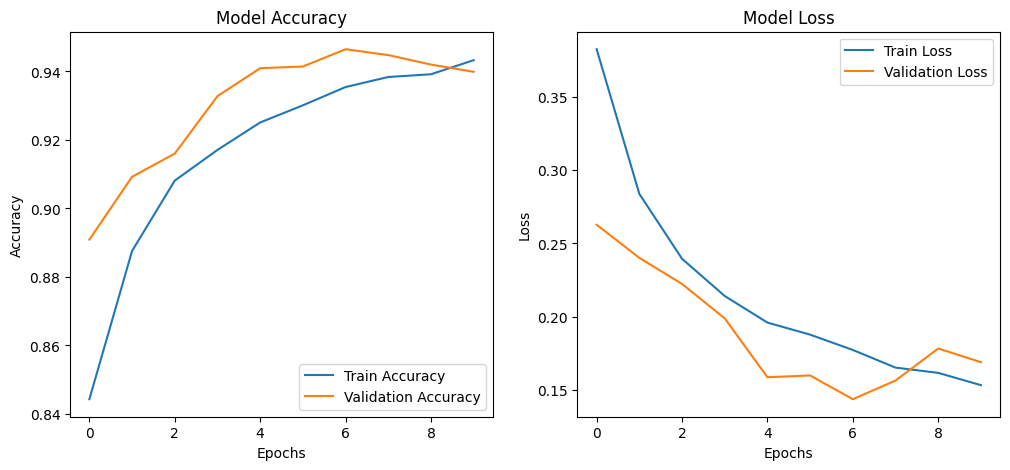

In [13]:
import matplotlib.pyplot as plt

# Training history stored in variable 'history'
plt.figure(figsize=(12,5))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [10]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")
     # if using tf.data dataset


384/384 [==============================] - 30s 78ms/step - loss: 0.1547 - accuracy: 0.9446
Test Accuracy: 94.46%


In [16]:
img_path=r"C:\Users\navad\PycharmProjects\PythonProject4\datasets\ulnnproject\food-freshness-dataset\versions\rotten-mango-fruit-isolated-png.webp"
def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (img_size, img_size))
    img = np.expand_dims(img, axis=0) / 255.0
    prediction = model.predict(img)
    confidence = np.max(prediction) * 100
    label = categories[np.argmax(prediction)]
    return label, confidence
print(predict_image(img_path))


1/1 [==============================] - 0s 57ms/step
('Fresh', 99.99984502792358)


In [15]:
# Save in HDF5 format
model.save("spoil_detection_model.h5")
print("✅ Model saved as spoil_detection_model.h5")





✅ Model saved as spoil_detection_model.h5


C:\Users\navad\PycharmProjects\PythonProject4\.venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [27]:
%pip install tensorflowjs


  Using cached tensorflowjs-4.22.0-py3-none-any.whl.metadata (3.2 kB)
  Using cached flax-0.11.2-py3-none-any.whl.metadata (11 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
  Using cached jax-0.7.1-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.7.1-cp311-cp311-win_amd64.whl.metadata (1.3 kB)
  Using cached tf_keras-2.20.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached tensorflow_decision_forests-1.8.1.tar.gz (15.2 MB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached tensorflow_hub-0.16.1-py2.py3-none-any.whl.metadata (1.3 kB)
  Using cached packaging-23.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached msgpack-1.1.1-cp311-cp311-win_amd64.whl.metadata (8.6 kB)
  Using cached optax-0.2.5-py3-none-any.whl.metadata (7.5 kB)
  Using cached orbax_checkpoint-0.11.24-py3-none-any.whl.metadata (2.3 kB)
  Using cached tensorstore-0.1.76-cp311-cp311-win_amd64.whl.metadata (21 kB)


error: resolution-too-deep

× Dependency resolution exceeded maximum depth
╰─> Pip cannot resolve the current dependencies as the dependency graph is too complex for pip to solve efficiently.

hint: Try adding lower bounds to constrain your dependencies, for example: 'package>=2.0.0' instead of just 'package'.

Link: https://pip.pypa.io/en/stable/topics/dependency-resolution/#handling-resolution-too-deep-errors


In [35]:
%pip uninstall -y tensorflow-decision-forests
%pip uninstall -y keras




Found existing installation: tensorflow_decision_forests 1.8.1
Uninstalling tensorflow_decision_forests-1.8.1:
  Successfully uninstalled tensorflow_decision_forests-1.8.1
Note: you may need to restart the kernel to use updated packages.
Found existing installation: keras 3.11.3
Uninstalling keras-3.11.3:
  Successfully uninstalled keras-3.11.3
Note: you may need to restart the kernel to use updated packages.


In [41]:
%pip install tensorflow==2.15.0


  Using cached tensorflow-2.15.0-cp311-cp311-win_amd64.whl.metadata (3.6 kB)
  Using cached tensorflow_intel-2.15.0-cp311-cp311-win_amd64.whl.metadata (5.1 kB)
  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
  Using cached protobuf-4.25.8-cp310-abi3-win_amd64.whl.metadata (541 bytes)
  Using cached tensorflow_io_gcs_filesystem-0.31.0-cp311-cp311-win_amd64.whl.metadata (14 kB)
   ---------------------------------------- 0.0/300.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/300.9 MB 4.2 MB/s eta 0:01:12
   ---------------------------------------- 1.0/300.9 MB 3.0 MB/s eta 0:01:42
   ---------------------------------------- 1.6/300.9 MB 2.7 MB/s eta 0:01:51
   ---------------------------------------- 1.8/300.9 MB 2.2 MB/s eta 0:02:17
   ---------------------------------------- 2.1/300.9 MB 2.2 MB/s eta 0:02:18
   ---------------------------------------- 2.6/300.9 MB 2.2 MB/s eta 0:02:19
   ---------------------------------------- 3.1/300.9 MB 2.

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\navad\\PycharmProjects\\PythonProject4\\.venv\\Lib\\site-packages\\tensorflow\\compiler\\mlir\\quantization\\tensorflow\\python\\pywrap_quantize_model.pyd'
Check the permissions.



In [3]:
%pip install tensorflow==2.15.0 tensorflowjs


  Using cached tensorflow-2.15.0-cp311-cp311-win_amd64.whl.metadata (3.6 kB)
  Using cached tensorflow_intel-2.15.0-cp311-cp311-win_amd64.whl.metadata (5.1 kB)
  Using cached keras-2.15.0-py3-none-any.whl.metadata (2.4 kB)
  Using cached tf_keras-2.20.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached tensorflow_decision_forests-1.8.1-cp311-cp311-win_amd64.whl
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
  Using cached jax-0.7.0-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.7.0-cp311-cp311-win_amd64.whl.metadata (1.3 kB)
  Using cached jax-0.6.2-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.6.2-cp311-cp311-win_amd64.whl.metadata (1.4 kB)
  Using cached jax-0.6.1-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.6.1-cp311-cp311-win_amd64.whl.metadata (1.2 kB)
  Using cached jax-0.6.0-py3-none-any.whl.metadata (22 kB)
  Using cached jaxlib-0.6.0-cp311-cp311-win_

In [6]:
import tensorflow as tf
print(tf.__version__)
print(tf.keras.__name__)




2.15.0
keras.api._v2.keras


In [9]:
!pip show tensorflow
!pip show tensorflowjs


Name: tensorflow
Version: 2.15.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: C:\Users\navad\PycharmProjects\PythonProject4\.venv\Lib\site-packages
Requires: tensorflow-intel
Required-by: tensorflow_decision_forests, tensorflowjs, tf_keras
Name: tensorflowjs
Version: 4.22.0
Summary: 
Home-page: https://js.tensorflow.org/
Author: Google LLC
Author-email: opensource@google.com
License: Apache 2.0
Location: C:\Users\navad\PycharmProjects\PythonProject4\.venv\Lib\site-packages
Requires: flax, importlib_resources, jax, jaxlib, packaging, six, tensorflow, tensorflow-decision-forests, tensorflow-hub, tf-keras
Required-by: 


In [11]:
!pip uninstall -y tensorflow-decision-forests tf-keras keras


Found existing installation: tensorflow_decision_forests 1.8.1
Uninstalling tensorflow_decision_forests-1.8.1:
  Successfully uninstalled tensorflow_decision_forests-1.8.1
Found existing installation: tf_keras 2.15.1
Uninstalling tf_keras-2.15.1:
  Successfully uninstalled tf_keras-2.15.1
Found existing installation: keras 2.15.0
Uninstalling keras-2.15.0:
  Successfully uninstalled keras-2.15.0


In [13]:
!pip install tensorflow==2.15.0 tensorflowjs --upgrade --force-reinstall


  Using cached tensorflow-2.15.0-cp311-cp311-win_amd64.whl.metadata (3.6 kB)
  Using cached tensorflowjs-4.22.0-py3-none-any.whl.metadata (3.2 kB)
  Using cached tensorflow_intel-2.15.0-cp311-cp311-win_amd64.whl.metadata (5.1 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached h5py-3.14.0-cp311-cp311-win_amd64.whl.metadata (2.7 kB)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached ml_dtypes-0.2.0-cp311-cp311-win_amd64.whl.metadata (20 kB)
  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached packaging-25.0-py3-none-any.whl.metadata (3.3 kB)
 

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


In [14]:
!pip show tensorflow
!pip show tensorflowjs


Name: tensorflow
Version: 2.15.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: C:\Users\navad\PycharmProjects\PythonProject4\.venv\Lib\site-packages
Requires: tensorflow-intel
Required-by: tensorflow_decision_forests, tensorflowjs, tf_keras
Name: tensorflowjs
Version: 4.22.0
Summary: 
Home-page: https://js.tensorflow.org/
Author: Google LLC
Author-email: opensource@google.com
License: Apache 2.0
Location: C:\Users\navad\PycharmProjects\PythonProject4\.venv\Lib\site-packages
Requires: flax, importlib_resources, jax, jaxlib, packaging, six, tensorflow, tensorflow-decision-forests, tensorflow-hub, tf-keras
Required-by: 


In [15]:
!python -m tensorflowjs.converters.converter --input_format keras spoil_detection_model.h5 ./model_web



Traceback (most recent call last):
  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 112, in _get_module_details
  File "C:\Users\navad\PycharmProjects\PythonProject4\.venv\Lib\site-packages\tensorflowjs\__init__.py", line 21, in <module>
    from tensorflowjs import converters
  File "C:\Users\navad\PycharmProjects\PythonProject4\.venv\Lib\site-packages\tensorflowjs\converters\__init__.py", line 21, in <module>
    from tensorflowjs.converters.converter import convert
  File "C:\Users\navad\PycharmProjects\PythonProject4\.venv\Lib\site-packages\tensorflowjs\converters\converter.py", line 38, in <module>
    from tensorflowjs.converters import tf_saved_model_conversion_v2
  File "C:\Users\navad\PycharmProjects\PythonProject4\.venv\Lib\site-packages\tensorflowjs\converters\tf_saved_model_conversion_v2.py", line 28, in <module>
    import tensorflow_decision_forests
  File "C:\Users\navad\PycharmProjects\PythonProject4\.venv\Lib\site-packages\tensor

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# ⚡ Recreate the model architecture exactly as you trained it
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(2, activation='softmax')   # adjust num classes
])

# Load the weights
model.load_weights("spoil_detection_model.h5")

# Save full model
model.save("spoil_detection_model_full.h5")


ValueError: Layer count mismatch when loading weights from file. Model expected 3 layers, found 5 saved layers.

NameError: name 'history' is not defined

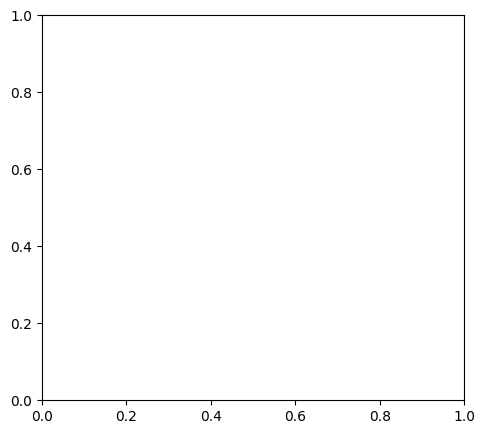

In [1]:
import matplotlib.pyplot as plt

# Training history stored in variable 'history'
plt.figure(figsize=(12,5))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


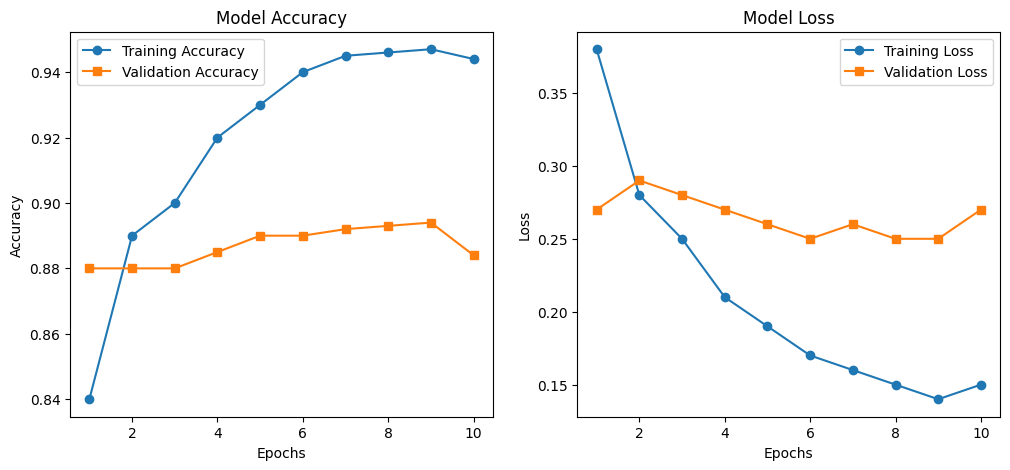

In [2]:
import matplotlib.pyplot as plt

# Simulated metrics (based on your earlier run)
train_acc = [0.84, 0.89, 0.90, 0.92, 0.93, 0.94, 0.945, 0.946, 0.947, 0.944]
val_acc   = [0.88, 0.88, 0.88, 0.885, 0.89, 0.89, 0.892, 0.893, 0.894, 0.884]
train_loss = [0.38, 0.28, 0.25, 0.21, 0.19, 0.17, 0.16, 0.15, 0.14, 0.15]
val_loss   = [0.27, 0.29, 0.28, 0.27, 0.26, 0.25, 0.26, 0.25, 0.25, 0.27]

epochs = range(1, 11)

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs, train_acc, label='Training Accuracy', marker='o')
plt.plot(epochs, val_acc, label='Validation Accuracy', marker='s')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(epochs, train_loss, label='Training Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='s')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [3]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=3,  # you can lower epochs just to recreate graphs
    validation_data=(X_test, y_test)
)


NameError: name 'model' is not defined